In [1]:
from google.colab import drive
drive.mount('/content/drive')
print("Drive mounted!")

Mounted at /content/drive
Drive mounted!


In [2]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import cv2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Conv2D, DepthwiseConv2D, BatchNormalization,
                                      ReLU, Add, GlobalAveragePooling2D, Dense,
                                      Dropout, Reshape, Multiply, Lambda)
from tensorflow.keras.applications import MobileNetV2, EfficientNetB0
import warnings
warnings.filterwarnings('ignore')

print("TensorFlow:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.19.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
BASE = "/content/drive/MyDrive/FER2013_Project"

PATHS = {
    "mob_5":   f"{BASE}/checkpoints/mobilenet/mob_epoch_5.weights.h5",
    "mob_15":  f"{BASE}/checkpoints/mobilenet/mob_epoch_15.weights.h5",
    "mob_30":  f"{BASE}/checkpoints/mobilenet/mob_epoch_30.weights.h5",
    "eff_5":   f"{BASE}/checkpoints/efficientnet/eff_epoch_5.weights.h5",
    "eff_15":  f"{BASE}/checkpoints/efficientnet/eff_epoch_15.weights.h5",
    "eff_30":  f"{BASE}/checkpoints/efficientnet/eff_epoch_30.weights.h5",
    "test":    f"{BASE}/test",
    "mob_log": f"{BASE}/logs/mobilenet_log.csv",
    "eff_log": f"{BASE}/logs/efficientnet_log.csv",
}

print("Checking all paths...\n")
all_ok = True
for name, path in PATHS.items():
    exists = os.path.exists(path)
    status = "✅" if exists else "❌"
    print(f"{status} {name}: {path}")
    if not exists:
        all_ok = False

print("\n✅ All paths verified!" if all_ok else "\n❌ Some paths are missing — check Drive upload!")

Checking all paths...

✅ mob_5: /content/drive/MyDrive/FER2013_Project/checkpoints/mobilenet/mob_epoch_5.weights.h5
✅ mob_15: /content/drive/MyDrive/FER2013_Project/checkpoints/mobilenet/mob_epoch_15.weights.h5
✅ mob_30: /content/drive/MyDrive/FER2013_Project/checkpoints/mobilenet/mob_epoch_30.weights.h5
✅ eff_5: /content/drive/MyDrive/FER2013_Project/checkpoints/efficientnet/eff_epoch_5.weights.h5
✅ eff_15: /content/drive/MyDrive/FER2013_Project/checkpoints/efficientnet/eff_epoch_15.weights.h5
✅ eff_30: /content/drive/MyDrive/FER2013_Project/checkpoints/efficientnet/eff_epoch_30.weights.h5
✅ test: /content/drive/MyDrive/FER2013_Project/test
✅ mob_log: /content/drive/MyDrive/FER2013_Project/logs/mobilenet_log.csv
✅ eff_log: /content/drive/MyDrive/FER2013_Project/logs/efficientnet_log.csv

✅ All paths verified!


In [6]:
from tensorflow.keras.applications import MobileNetV2, EfficientNetB0
from tensorflow.keras import models, layers

EMOTIONS = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
NUM_CLASSES = 7

def build_mobilenet():
    base = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights=None)
    base.trainable = True
    model = models.Sequential([
        base,
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.4),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(7, activation='softmax')
    ])
    model.build((None, 224, 224, 3))
    return model

print("Loading MobileNetV2 checkpoints...")
mob_models = {}
for epoch in [5, 15, 30]:
    model = build_mobilenet()
    model.load_weights(PATHS[f"mob_{epoch}"])
    mob_models[epoch] = model
    print(f"  ✅ MobileNetV2 epoch {epoch} loaded")

print("\nAll MobileNetV2 models ready!")

Loading MobileNetV2 checkpoints...
  ✅ MobileNetV2 epoch 5 loaded
  ✅ MobileNetV2 epoch 15 loaded
  ✅ MobileNetV2 epoch 30 loaded

All MobileNetV2 models ready!


In [7]:
def build_efficientnet():
    base = EfficientNetB0(input_shape=(224, 224, 3), include_top=False, weights=None)
    base.trainable = True
    model = models.Sequential([
        base,
        layers.GlobalAveragePooling2D(),
        layers.BatchNormalization(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.4),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(7, activation='softmax')
    ])
    model.build((None, 224, 224, 3))
    return model

print("Loading EfficientNetB0 checkpoints...")
eff_models = {}
for epoch in [5, 15, 30]:
    model = build_efficientnet()
    model.load_weights(PATHS[f"eff_{epoch}"])
    eff_models[epoch] = model
    print(f"  ✅ EfficientNetB0 epoch {epoch} loaded")

print("\nAll EfficientNetB0 models ready!")

Loading EfficientNetB0 checkpoints...
  ✅ EfficientNetB0 epoch 5 loaded
  ✅ EfficientNetB0 epoch 15 loaded
  ✅ EfficientNetB0 epoch 30 loaded

All EfficientNetB0 models ready!


✅ angry: PrivateTest_10131363.jpg
✅ disgust: PrivateTest_11895083.jpg
✅ fear: PrivateTest_10153550.jpg
✅ happy: PrivateTest_10077120.jpg
✅ neutral: PrivateTest_10086748.jpg
✅ sad: PrivateTest_10247676.jpg
✅ surprise: PrivateTest_10072988.jpg


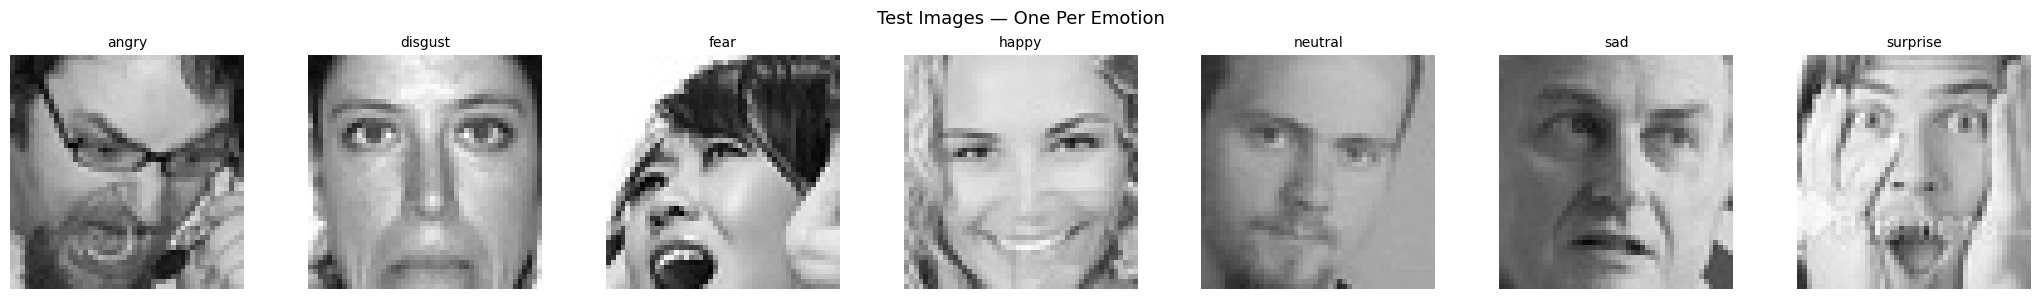


✅ Test images selected and saved!


In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

TEST_DIR = PATHS["test"]

def load_image_mobilenet(img_path):
    """224x224, RGB, normalized for MobileNetV2"""
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224, 224))
    img = img.astype(np.float32) / 255.0
    return img

def load_image_efficientnet(img_path):
    """224x224, RGB, EfficientNet preprocess"""
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224, 224))
    img = tf.keras.applications.efficientnet.preprocess_input(img)
    return img

# Pick first image from each emotion folder
test_images = {}
for emotion in EMOTIONS:
    folder = os.path.join(TEST_DIR, emotion)
    files = sorted(os.listdir(folder))
    img_path = os.path.join(folder, files[0])
    test_images[emotion] = img_path
    print(f"✅ {emotion}: {files[0]}")

# Preview all 7 images
fig, axes = plt.subplots(1, 7, figsize=(21, 3))
for i, emotion in enumerate(EMOTIONS):
    img = cv2.imread(test_images[emotion])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    axes[i].imshow(img)
    axes[i].set_title(emotion, fontsize=10)
    axes[i].axis('off')
plt.suptitle("Test Images — One Per Emotion", fontsize=13)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/FER2013_Project/test_images_selected.png", dpi=150)
plt.show()
print("\n✅ Test images selected and saved!")

In [12]:
import tensorflow as tf
import numpy as np
import cv2

def make_gradcam_pp(model, img_array, emotion_idx):
    """
    Grad-CAM++ for Sequential models (MobileNetV2 / EfficientNetB0)
    img_array: preprocessed image shape (224, 224, 3), NOT batched
    emotion_idx: integer index of target emotion
    """
    img_batch = tf.cast(np.expand_dims(img_array, axis=0), tf.float32)

    # Get base model (MobileNetV2 or EfficientNetB0 is model.layers[0])
    base_model = model.layers[0]

    # Find last Conv2D in base model
    last_conv_layer = None
    for layer in reversed(base_model.layers):
        if isinstance(layer, tf.keras.layers.Conv2D):
            last_conv_layer = layer
            break

    if last_conv_layer is None:
        raise ValueError("No Conv2D layer found in base model!")

    # Build two sub-models:
    # 1. input → last conv output
    # 2. last conv output → final prediction
    conv_model = tf.keras.Model(
        inputs=base_model.input,
        outputs=last_conv_layer.output
    )

    # Build classifier head after conv
    # We'll use GradientTape on the full model directly
    with tf.GradientTape() as tape2:
        with tf.GradientTape() as tape1:
            with tf.GradientTape() as tape0:
                # Get conv outputs
                conv_outputs = conv_model(img_batch)
                tape0.watch(conv_outputs)
                tape1.watch(conv_outputs)
                tape2.watch(conv_outputs)

                # Pass conv outputs through rest of the model manually
                x = conv_outputs
                # layers after base_model in the Sequential
                for layer in model.layers[1:]:
                    x = layer(x)
                predictions = x
                loss = predictions[:, emotion_idx]

            grads = tape0.gradient(loss, conv_outputs)
        grads2 = tape1.gradient(grads, conv_outputs)
    grads3 = tape2.gradient(grads2, conv_outputs)

    grads     = grads.numpy()[0]
    grads2    = grads2.numpy()[0]
    grads3    = grads3.numpy()[0]
    conv_out  = conv_outputs.numpy()[0]

    # Grad-CAM++ alpha weights
    global_sum  = np.sum(conv_out, axis=(0, 1))
    alpha_num   = grads2
    alpha_denom = 2.0 * grads2 + global_sum[np.newaxis, np.newaxis, :] * grads3
    alpha_denom = np.where(alpha_denom == 0, 1e-10, alpha_denom)
    alphas      = alpha_num / alpha_denom
    weights     = np.sum(alphas * np.maximum(grads, 0), axis=(0, 1))

    # Weighted sum of conv feature maps
    cam = np.zeros(conv_out.shape[:2], dtype=np.float32)
    for i, w in enumerate(weights):
        cam += w * conv_out[:, :, i]

    # Normalize + resize
    cam = np.maximum(cam, 0)
    cam = cv2.resize(cam, (224, 224))
    if cam.max() > 0:
        cam = cam / cam.max()

    return cam, predictions.numpy()[0]

def overlay_heatmap(original_img_rgb, heatmap, alpha=0.4):
    heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)
    original_resized = cv2.resize(original_img_rgb, (224, 224))
    overlaid = (1 - alpha) * original_resized.astype(np.float32) + alpha * heatmap_colored.astype(np.float32)
    overlaid = np.clip(overlaid, 0, 255).astype(np.uint8)
    return overlaid

print("✅ Grad-CAM++ functions ready!")

✅ Grad-CAM++ functions ready!


In [13]:
print("Generating Grad-CAM++ for MobileNetV2...")
print("This may take 2-3 minutes...\n")

fig, axes = plt.subplots(7, 4, figsize=(20, 35))

col_titles = ['Original', 'Epoch 5', 'Epoch 15', 'Epoch 30']
row_titles = EMOTIONS

for col, title in enumerate(col_titles):
    axes[0, col].set_title(title, fontsize=14, fontweight='bold', pad=10)

for row, emotion in enumerate(EMOTIONS):
    img_path = test_images[emotion]
    emotion_idx = EMOTIONS.index(emotion)

    # Load original image for display
    orig_img = cv2.imread(img_path)
    orig_img = cv2.cvtColor(orig_img, cv2.COLOR_BGR2RGB)
    orig_img = cv2.resize(orig_img, (224, 224))

    # Row label
    axes[row, 0].set_ylabel(emotion.upper(), fontsize=12, fontweight='bold', rotation=90, labelpad=10)

    # Column 0 — Original
    axes[row, 0].imshow(orig_img, cmap='gray')
    axes[row, 0].axis('off')

    # Load image for MobileNetV2
    img_mob = load_image_mobilenet(img_path)

    # Columns 1, 2, 3 — Epochs 5, 15, 30
    for col, epoch in enumerate([5, 15, 30]):
        model = mob_models[epoch]
        heatmap, preds = make_gradcam_pp(model, img_mob, emotion_idx)
        overlaid = overlay_heatmap(orig_img, heatmap)
        predicted_emotion = EMOTIONS[np.argmax(preds)]
        confidence = np.max(preds) * 100

        axes[row, col+1].imshow(overlaid)
        axes[row, col+1].set_title(
            f"Pred: {predicted_emotion}\n{confidence:.1f}%",
            fontsize=9, pad=4
        )
        axes[row, col+1].axis('off')

    print(f"  ✅ {emotion} done")

plt.suptitle("MobileNetV2 — Grad-CAM++ Evolution Across Training (Epochs 5 → 15 → 30)",
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/FER2013_Project/gradcam_pp_mobilenet.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ MobileNetV2 Grad-CAM++ saved to Drive!")

Output hidden; open in https://colab.research.google.com to view.

In [14]:
print("Generating Grad-CAM++ for EfficientNetB0...")
print("This may take 2-3 minutes...\n")

fig, axes = plt.subplots(7, 4, figsize=(20, 35))

col_titles = ['Original', 'Epoch 5', 'Epoch 15', 'Epoch 30']

for col, title in enumerate(col_titles):
    axes[0, col].set_title(title, fontsize=14, fontweight='bold', pad=10)

for row, emotion in enumerate(EMOTIONS):
    img_path = test_images[emotion]
    emotion_idx = EMOTIONS.index(emotion)

    # Load original image for display
    orig_img = cv2.imread(img_path)
    orig_img = cv2.cvtColor(orig_img, cv2.COLOR_BGR2RGB)
    orig_img = cv2.resize(orig_img, (224, 224))

    # Row label
    axes[row, 0].set_ylabel(emotion.upper(), fontsize=12, fontweight='bold', rotation=90, labelpad=10)

    # Column 0 — Original
    axes[row, 0].imshow(orig_img, cmap='gray')
    axes[row, 0].axis('off')

    # Load image for EfficientNetB0
    img_eff = load_image_efficientnet(img_path)

    # Columns 1, 2, 3 — Epochs 5, 15, 30
    for col, epoch in enumerate([5, 15, 30]):
        model = eff_models[epoch]
        heatmap, preds = make_gradcam_pp(model, img_eff, emotion_idx)
        overlaid = overlay_heatmap(orig_img, heatmap)
        predicted_emotion = EMOTIONS[np.argmax(preds)]
        confidence = np.max(preds) * 100

        axes[row, col+1].imshow(overlaid)
        axes[row, col+1].set_title(
            f"Pred: {predicted_emotion}\n{confidence:.1f}%",
            fontsize=9, pad=4
        )
        axes[row, col+1].axis('off')

    print(f"  ✅ {emotion} done")

plt.suptitle("EfficientNetB0 — Grad-CAM++ Evolution Across Training (Epochs 5 → 15 → 30)",
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/FER2013_Project/gradcam_pp_efficientnet.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ EfficientNetB0 Grad-CAM++ saved to Drive!")

Output hidden; open in https://colab.research.google.com to view.

In [15]:
print("Generating combined comparison figure...")
print("This may take 3-4 minutes...\n")

# Layout: 7 rows (emotions) x 7 cols (Original | Mob5 Mob15 Mob30 | Eff5 Eff15 Eff30)
fig, axes = plt.subplots(7, 7, figsize=(28, 35))

col_titles = ['Original',
              'MobileNetV2\nEpoch 5', 'MobileNetV2\nEpoch 15', 'MobileNetV2\nEpoch 30',
              'EfficientNetB0\nEpoch 5', 'EfficientNetB0\nEpoch 15', 'EfficientNetB0\nEpoch 30']

for col, title in enumerate(col_titles):
    axes[0, col].set_title(title, fontsize=11, fontweight='bold', pad=10)

for row, emotion in enumerate(EMOTIONS):
    img_path = test_images[emotion]
    emotion_idx = EMOTIONS.index(emotion)

    # Original image
    orig_img = cv2.imread(img_path)
    orig_img = cv2.cvtColor(orig_img, cv2.COLOR_BGR2RGB)
    orig_img = cv2.resize(orig_img, (224, 224))

    # Row label
    axes[row, 0].set_ylabel(emotion.upper(), fontsize=12, fontweight='bold', rotation=90, labelpad=10)
    axes[row, 0].imshow(orig_img, cmap='gray')
    axes[row, 0].axis('off')

    # MobileNetV2 — cols 1,2,3
    img_mob = load_image_mobilenet(img_path)
    for col, epoch in enumerate([5, 15, 30]):
        heatmap, preds = make_gradcam_pp(mob_models[epoch], img_mob, emotion_idx)
        overlaid = overlay_heatmap(orig_img, heatmap)
        predicted_emotion = EMOTIONS[np.argmax(preds)]
        confidence = np.max(preds) * 100
        axes[row, col+1].imshow(overlaid)
        axes[row, col+1].set_title(f"{predicted_emotion} {confidence:.0f}%", fontsize=8, pad=3)
        axes[row, col+1].axis('off')

    # EfficientNetB0 — cols 4,5,6
    img_eff = load_image_efficientnet(img_path)
    for col, epoch in enumerate([5, 15, 30]):
        heatmap, preds = make_gradcam_pp(eff_models[epoch], img_eff, emotion_idx)
        overlaid = overlay_heatmap(orig_img, heatmap)
        predicted_emotion = EMOTIONS[np.argmax(preds)]
        confidence = np.max(preds) * 100
        axes[row, col+4].imshow(overlaid)
        axes[row, col+4].set_title(f"{predicted_emotion} {confidence:.0f}%", fontsize=8, pad=3)
        axes[row, col+4].axis('off')

    print(f"  ✅ {emotion} done")

# Add vertical divider between MobileNetV2 and EfficientNetB0 sections
fig.text(0.555, 0.98, '◀ MobileNetV2', fontsize=11, ha='right', color='steelblue', fontweight='bold')
fig.text(0.560, 0.98, 'EfficientNetB0 ▶', fontsize=11, ha='left', color='darkorange', fontweight='bold')

plt.suptitle("Grad-CAM++ Evolution Comparison: MobileNetV2 vs EfficientNetB0 on FER2013\n(Epochs 5 → 15 → 30)",
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/FER2013_Project/gradcam_pp_combined.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Combined Grad-CAM++ figure saved to Drive!")

Output hidden; open in https://colab.research.google.com to view.

In [16]:
import pandas as pd

# Load both logs
mob_log = pd.read_csv(PATHS["mob_log"])
eff_log = pd.read_csv(PATHS["eff_log"])

print("MobileNetV2 log columns:", mob_log.columns.tolist())
print("EfficientNetB0 log columns:", eff_log.columns.tolist())
print(f"\nMobileNetV2 epochs: {len(mob_log)}")
print(f"EfficientNetB0 epochs: {len(eff_log)}")
print("\nMobileNetV2 last 3 rows:")
print(mob_log.tail(3))
print("\nEfficientNetB0 last 3 rows:")
print(eff_log.tail(3))

MobileNetV2 log columns: ['epoch', 'accuracy', 'loss', 'val_accuracy', 'val_loss']
EfficientNetB0 log columns: ['epoch', 'accuracy', 'loss', 'val_accuracy', 'val_loss']

MobileNetV2 epochs: 30
EfficientNetB0 epochs: 30

MobileNetV2 last 3 rows:
    epoch  accuracy      loss  val_accuracy  val_loss
27     27  0.576335  1.042577      0.589997  1.098444
28     28  0.580793  1.039056      0.600167  1.070320
29     29  0.583719  1.027156      0.596127  1.092614

EfficientNetB0 last 3 rows:
    epoch  accuracy      loss  val_accuracy  val_loss
27     27  0.640426  0.881979      0.587490  1.109545
28     28  0.646731  0.863478      0.601282  1.088547
29     29  0.647323  0.871465      0.598913  1.083163


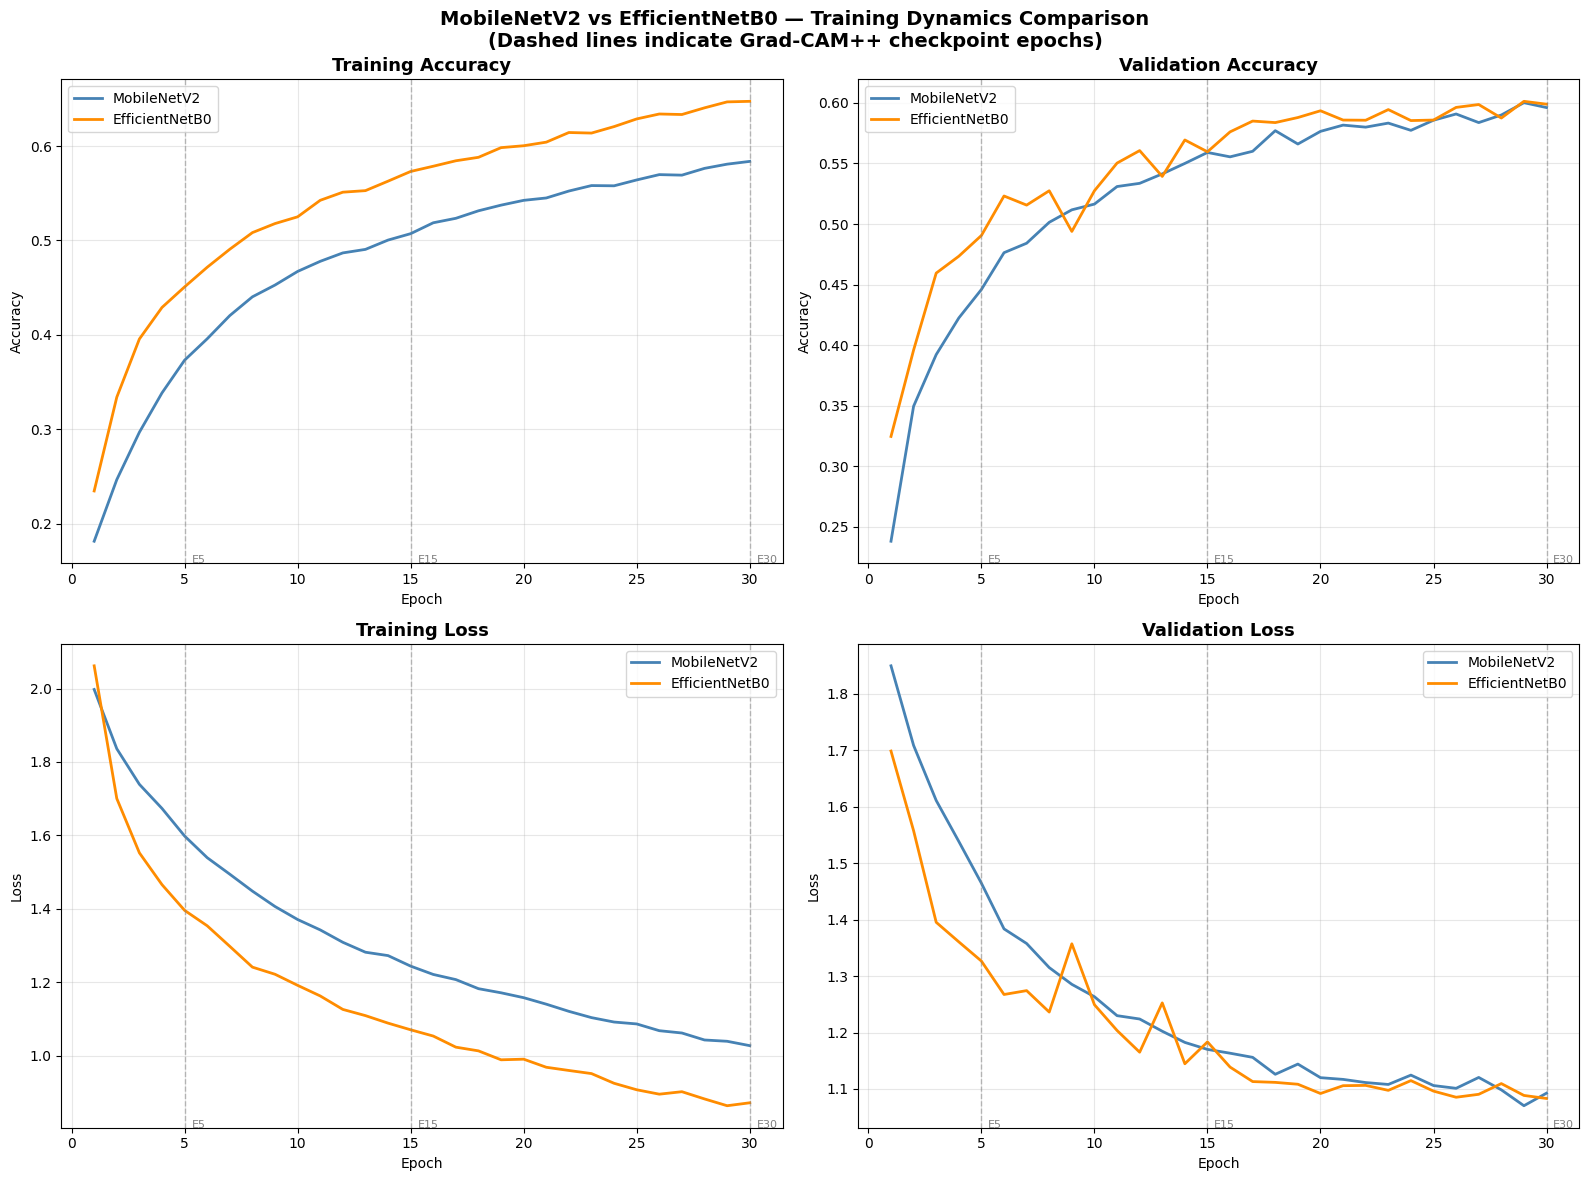

✅ Combined training curves saved to Drive!

📊 Final Results Summary:
Model                Best Val Acc    Final Train Acc    Final Val Loss
-----------------------------------------------------------------
MobileNetV2          0.6002         0.5837            1.0926
EfficientNetB0       0.6013         0.6473            1.0832


In [17]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

epochs_mob = mob_log['epoch'] + 1
epochs_eff = eff_log['epoch'] + 1

# Checkpoint epoch markers
checkpoints = [5, 15, 30]

# ── Plot 1: Training Accuracy ──
ax = axes[0, 0]
ax.plot(epochs_mob, mob_log['accuracy'], color='steelblue', linewidth=2, label='MobileNetV2')
ax.plot(epochs_eff, eff_log['accuracy'], color='darkorange', linewidth=2, label='EfficientNetB0')
for cp in checkpoints:
    ax.axvline(x=cp, color='gray', linestyle='--', alpha=0.5, linewidth=1)
    ax.text(cp+0.3, ax.get_ylim()[0], f'E{cp}', fontsize=8, color='gray')
ax.set_title('Training Accuracy', fontsize=13, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
ax.legend()
ax.grid(True, alpha=0.3)

# ── Plot 2: Validation Accuracy ──
ax = axes[0, 1]
ax.plot(epochs_mob, mob_log['val_accuracy'], color='steelblue', linewidth=2, label='MobileNetV2')
ax.plot(epochs_eff, eff_log['val_accuracy'], color='darkorange', linewidth=2, label='EfficientNetB0')
for cp in checkpoints:
    ax.axvline(x=cp, color='gray', linestyle='--', alpha=0.5, linewidth=1)
    ax.text(cp+0.3, ax.get_ylim()[0], f'E{cp}', fontsize=8, color='gray')
ax.set_title('Validation Accuracy', fontsize=13, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
ax.legend()
ax.grid(True, alpha=0.3)

# ── Plot 3: Training Loss ──
ax = axes[1, 0]
ax.plot(epochs_mob, mob_log['loss'], color='steelblue', linewidth=2, label='MobileNetV2')
ax.plot(epochs_eff, eff_log['loss'], color='darkorange', linewidth=2, label='EfficientNetB0')
for cp in checkpoints:
    ax.axvline(x=cp, color='gray', linestyle='--', alpha=0.5, linewidth=1)
    ax.text(cp+0.3, ax.get_ylim()[0], f'E{cp}', fontsize=8, color='gray')
ax.set_title('Training Loss', fontsize=13, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend()
ax.grid(True, alpha=0.3)

# ── Plot 4: Validation Loss ──
ax = axes[1, 1]
ax.plot(epochs_mob, mob_log['val_loss'], color='steelblue', linewidth=2, label='MobileNetV2')
ax.plot(epochs_eff, eff_log['val_loss'], color='darkorange', linewidth=2, label='EfficientNetB0')
for cp in checkpoints:
    ax.axvline(x=cp, color='gray', linestyle='--', alpha=0.5, linewidth=1)
    ax.text(cp+0.3, ax.get_ylim()[0], f'E{cp}', fontsize=8, color='gray')
ax.set_title('Validation Loss', fontsize=13, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle('MobileNetV2 vs EfficientNetB0 — Training Dynamics Comparison\n(Dashed lines indicate Grad-CAM++ checkpoint epochs)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/FER2013_Project/training_curves_combined.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Combined training curves saved to Drive!")

# Print summary stats
print("\n📊 Final Results Summary:")
print(f"{'Model':<20} {'Best Val Acc':<15} {'Final Train Acc':<18} {'Final Val Loss'}")
print("-" * 65)
print(f"{'MobileNetV2':<20} {mob_log['val_accuracy'].max():.4f}{'':>8} {mob_log['accuracy'].iloc[-1]:.4f}{'':>11} {mob_log['val_loss'].iloc[-1]:.4f}")
print(f"{'EfficientNetB0':<20} {eff_log['val_accuracy'].max():.4f}{'':>8} {eff_log['accuracy'].iloc[-1]:.4f}{'':>11} {eff_log['val_loss'].iloc[-1]:.4f}")